In [96]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
warnings.filterwarnings('ignore')


In [121]:
df_transactions = pd.read_csv('./data/cleaned_data/transactions.csv')
display(df_transactions.head())

,unique_id,transaction_date,subscription_status,payment_source,product,certificate_voyage,transaction_fee,net_payment
0,9639a8028a06a8e6435f5fea20e96ce8,2022-08-22,no-subscription,BUY ME A COFFEE,DONATION,No Certificate,0.0,15.00
1,39568d99c5ee4923a0e8ac3bd917845b,2022-08-29,no-subscription,BUY ME A COFFEE,DONATION,No Certificate,0.0,105.00
2,d41d8cd98f00b204e9800998ecf8427e,2022-08-30,no-subscription,TAX REFUND,ADJUSTMENT,No Certificate,0.0,105.52
3,8b7703ef2e3c958a77487e5e1666d4ed,2022-10-04,no-subscription,BUY ME A COFFEE,DONATION,No Certificate,0.0,100.00
4,d41d8cd98f00b204e9800998ecf8427e,2022-10-20,no-subscription,SPREADSHOP,MERCHANDISE,No Certificate,0.0,12.00


In [122]:
# Examine the shape of the data
print(f"Shape of the DataFrame: {df_transactions.shape}")

# Inspect Data Types
print("\nData Types of Columns:")
print(df_transactions.dtypes)

# Summarize Numerical Features
print("\nDescriptive Statistics for Numerical Features:")
print(df_transactions.describe())

# Explore Categorical Features
print("\nUnique Values and Frequencies for Categorical Features:")
for column in df_transactions.select_dtypes(include=['object']):
    print(f"\nColumn: {column}")
    print(df_transactions[column].value_counts())

# Check for Missing Values
print("\nMissing Values:")
print(df_transactions.isnull().sum())
print("\nProportion of Missing Values:")
print(df_transactions.isnull().mean())

# Preliminary Insights
print("\nPreliminary Insights:")
# Analyze the results from the previous steps to gain preliminary insights about the data
# ... (This part requires manual inspection and interpretation of the output)

Shape of the DataFrame: (879, 8)

Data Types of Columns:
unique_id               object
transaction_date        object
subscription_status     object
payment_source          object
product                 object
certificate_voyage      object
transaction_fee        float64
net_payment            float64
dtype: object

Descriptive Statistics for Numerical Features:
       transaction_fee  net_payment
count       879.000000   879.000000
mean          0.506633     7.843311
std           0.520145    20.029156
min           0.000000    -0.300000
25%           0.300000     2.690000
50%           0.390000     2.690000
75%           0.470000     4.550000
max           6.100000   278.560000

Unique Values and Frequencies for Categorical Features:

Column: unique_id
unique_id
5387991b8a99a8c31f69e5bf40aa4f1c    23
6dfda0f5b98594883081641050e194f6    17
ec16654715192e1be051404870107589    17
524a699715291934292e574fe296d37d    16
5f7f81aa7fcbed4aae25a76ebaa958fb    16
                            

In [123]:
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 879 entries, 0 to 878
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   unique_id            879 non-null    object 
 1   transaction_date     879 non-null    object 
 2   subscription_status  879 non-null    object 
 3   payment_source       879 non-null    object 
 4   product              879 non-null    object 
 5   certificate_voyage   879 non-null    object 
 6   transaction_fee      879 non-null    float64
 7   net_payment          879 non-null    float64
dtypes: float64(2), object(6)
memory usage: 55.1+ KB


In [124]:
# Handle missing values
print("Missing values before handling:")
print(df_transactions.isnull().sum())

# Replace missing values in 'Transaction Date' with a placeholder or the most frequent date (depending on the context)
df_transactions['transaction_date'].fillna('', inplace=True)

# Replace missing values in numerical columns with the mean (or median)
numerical_cols = ['transaction_fee', 'net_payment']  
for col in numerical_cols:
    df_transactions[col].fillna(df_transactions[col].median(), inplace=True)  


for col in numerical_cols:  # Use the same numerical_cols as above
    Q1 = df_transactions[col].quantile(0.25)
    Q3 = df_transactions[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_transactions = df_transactions[(df_transactions[col] >= lower_bound) & (df_transactions[col] <= upper_bound)]


# Check for missing values after handling.
print("\nMissing values after handling:")
print(df_transactions.isnull().sum())

Missing values before handling:
unique_id              0
transaction_date       0
subscription_status    0
payment_source         0
product                0
certificate_voyage     0
transaction_fee        0
net_payment            0
dtype: int64

Missing values after handling:
unique_id              0
transaction_date       0
subscription_status    0
payment_source         0
product                0
certificate_voyage     0
transaction_fee        0
net_payment            0
dtype: int64


In [125]:
# Convert 'Transaction Date' to datetime objects
df_transactions['transaction_date'] = pd.to_datetime(df_transactions['transaction_date'], errors='coerce')

# Extract day of the week, month, and year
df_transactions['day_of_Week'] = df_transactions['transaction_date'].dt.dayofweek
df_transactions['month'] = df_transactions['transaction_date'].dt.month
df_transactions['year'] = df_transactions['transaction_date'].dt.year

# Calculate total transaction amount for each user
#df_transactions['total_tansaction_amount'] = df_transactions.groupby('unique_id')['net_payment'].transform('sum')

In [126]:
# Analyze transaction frequency over time
daily_transactions = df_transactions.groupby(df_transactions['transaction_date'].dt.date).size()
monthly_transactions = df_transactions.groupby(df_transactions['transaction_date'].dt.to_period('M')).size()
yearly_transactions = df_transactions.groupby(df_transactions['transaction_date'].dt.year).size()

# Calculate the average transaction amount and its distribution
average_transaction_amount = df_transactions['net_payment'].mean()
transaction_amount_distribution = df_transactions['net_payment'].describe()

# Print the results
print("Daily Transaction Frequency:")
display(daily_transactions)
print("\nMonthly Transaction Frequency:")
display(monthly_transactions)
print("\nYearly Transaction Frequency:")
display(yearly_transactions)
print("\nAverage Transaction Amount:", average_transaction_amount)
print("\nTransaction Amount Distribution:")
display(transaction_amount_distribution)

Daily Transaction Frequency:


transaction_date
2023-03-15    1
2023-04-06    1
2023-04-13    3
2023-04-28    1
2023-05-05    1
             ..
2025-02-22    3
2025-02-24    2
2025-02-26    1
2025-02-28    1
2025-03-02    1
Length: 326, dtype: int64


Monthly Transaction Frequency:


transaction_date
2023-03     1
2023-04     5
2023-05     3
2023-06     1
2023-07     4
2023-08     5
2023-09     5
2023-10     6
2023-11    11
2023-12    20
2024-01    21
2024-02    50
2024-03    30
2024-04    40
2024-05    36
2024-06    49
2024-07    33
2024-08    50
2024-09    31
2024-10    44
2024-11    38
2024-12    63
2025-01    47
2025-02    50
2025-03     1
Freq: M, dtype: int64


Yearly Transaction Frequency:


transaction_date
2023     61
2024    485
2025     98
dtype: int64


Average Transaction Amount: 2.922453416149069

Transaction Amount Distribution:


count    644.000000
mean       2.922453
std        0.542709
min        1.630000
25%        2.690000
50%        2.690000
75%        3.480000
max        4.550000
Name: net_payment, dtype: float64

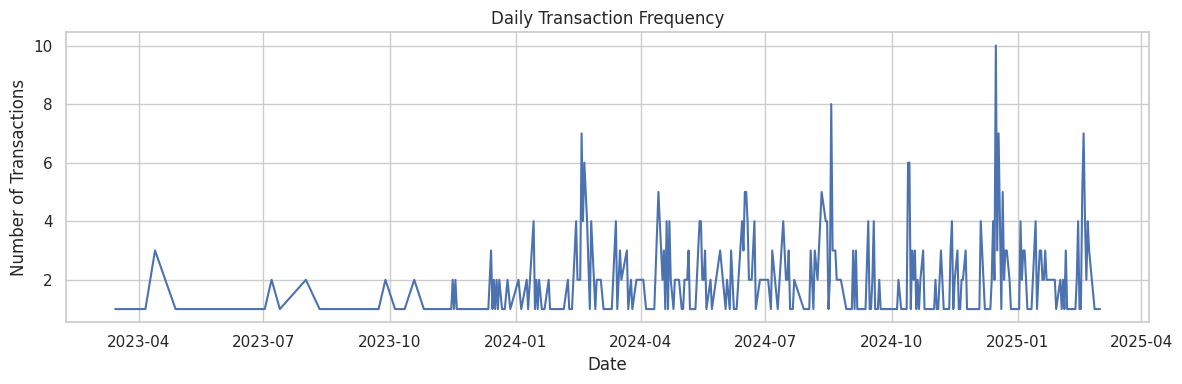

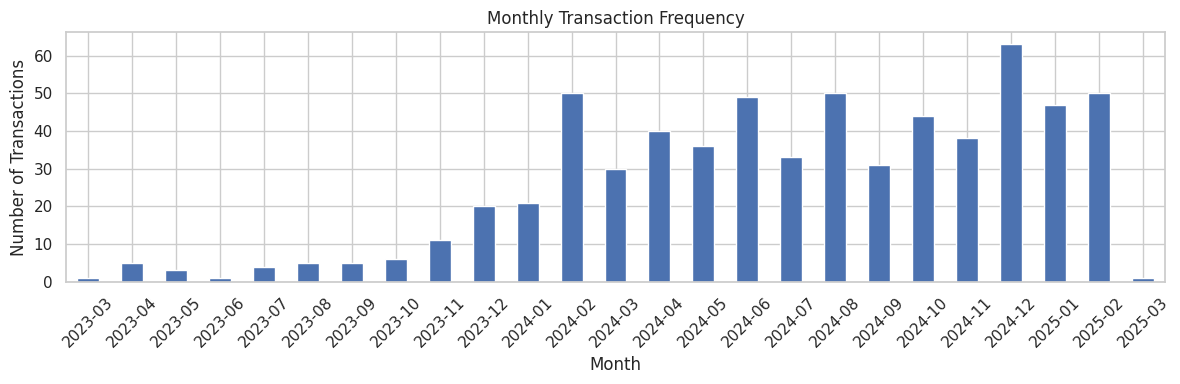

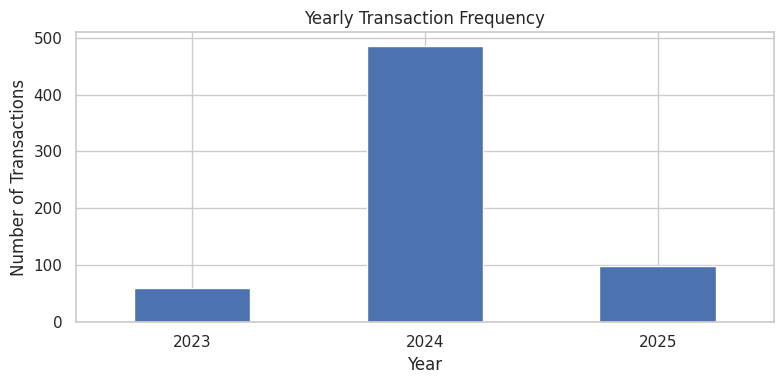

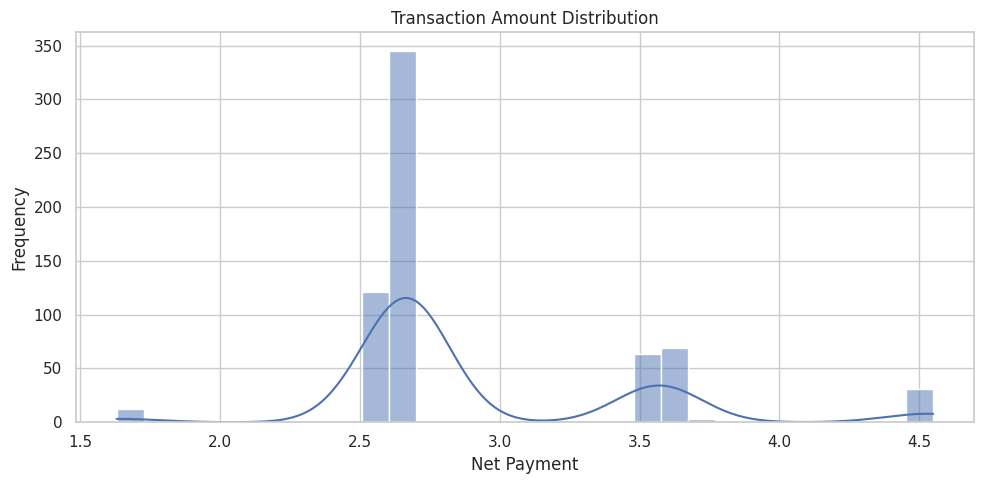

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plotting style
sns.set(style="whitegrid")

# Plot Daily Transactions
plt.figure(figsize=(12, 4))
daily_transactions.plot()
plt.title('Daily Transaction Frequency')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

# Plot Monthly Transactions
plt.figure(figsize=(12, 4))
monthly_transactions.plot(kind='bar')
plt.title('Monthly Transaction Frequency')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot Yearly Transactions
plt.figure(figsize=(8, 4))
yearly_transactions.plot(kind='bar')
plt.title('Yearly Transaction Frequency')
plt.xlabel('Year')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Plot Transaction Amount Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_transactions['net_payment'], kde=True, bins=30)
plt.title('Transaction Amount Distribution')
plt.xlabel('Net Payment')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


In [128]:
# Calculate average spending per customer
average_spending_per_customer = df_transactions.groupby(['unique_id'])['net_payment'].mean().reset_index()

# Explore distribution of spending across different products
spending_by_product = df_transactions.groupby('product')['net_payment'].sum().reset_index()

spending_by_month = df_transactions.groupby(['year','month'])['net_payment'].sum().reset_index()
# Print the results
print("Average Spending Per Customer:")
display(average_spending_per_customer)
print("\nSpending by Product:")
display(spending_by_product)

print("\nSpending per Month:")
display(spending_by_month)

Average Spending Per Customer:


,unique_id,net_payment
0,00c627b292f06962dcc156123be86379,3.59
1,044fb6bf6c427216e5f605b03a734a4b,3.57
2,0493ecd0031faddfd7be2e9b51f50c3c,3.59
3,0515f1d5ff21444477949063e1f475ee,3.59
4,059f1223b863548fc8bde71bd7c75704,4.49
...,...,...
238,fb5e11dcbcbdb3bfaf78cb48e43a4ebe,2.69
239,fcabcba3a962523832a74a904af02acb,2.69
240,fd156bd6e7dd15f87eac8d5fd54bac36,3.59
241,fd9cde9bdb0957f27b1421d2fa34d132,2.69



Spending by Product:


,product,net_payment
0,DONATION,123.04
1,PRODUCT - Voyage Certificate,504.49
2,SUBSCRIPTION - Junior Professional,1254.53



Spending per Month:


,year,month,net_payment
0,2023,3,4.55
1,2023,4,22.75
2,2023,5,13.65
3,2023,6,4.55
4,2023,7,18.20
5,2023,8,21.78
6,2023,9,14.02
7,2023,10,13.72
8,2023,11,27.36
9,2023,12,54.33


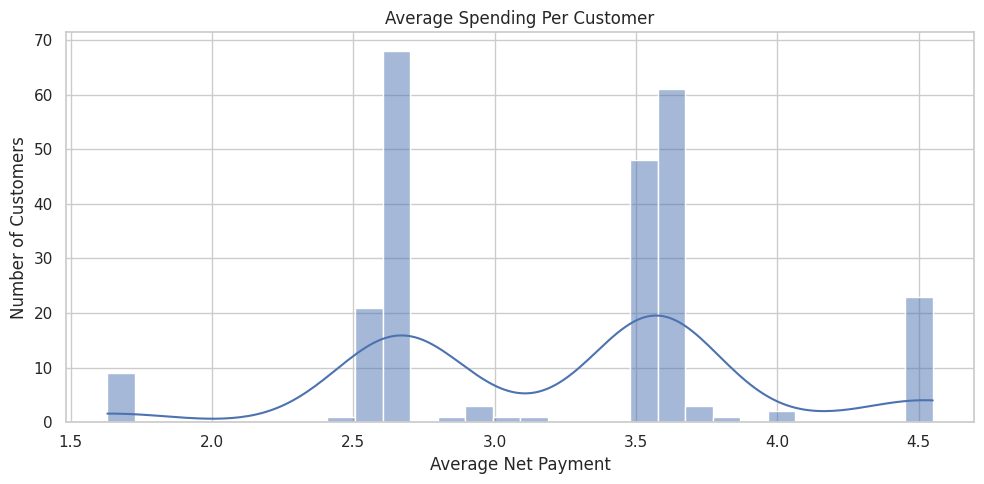

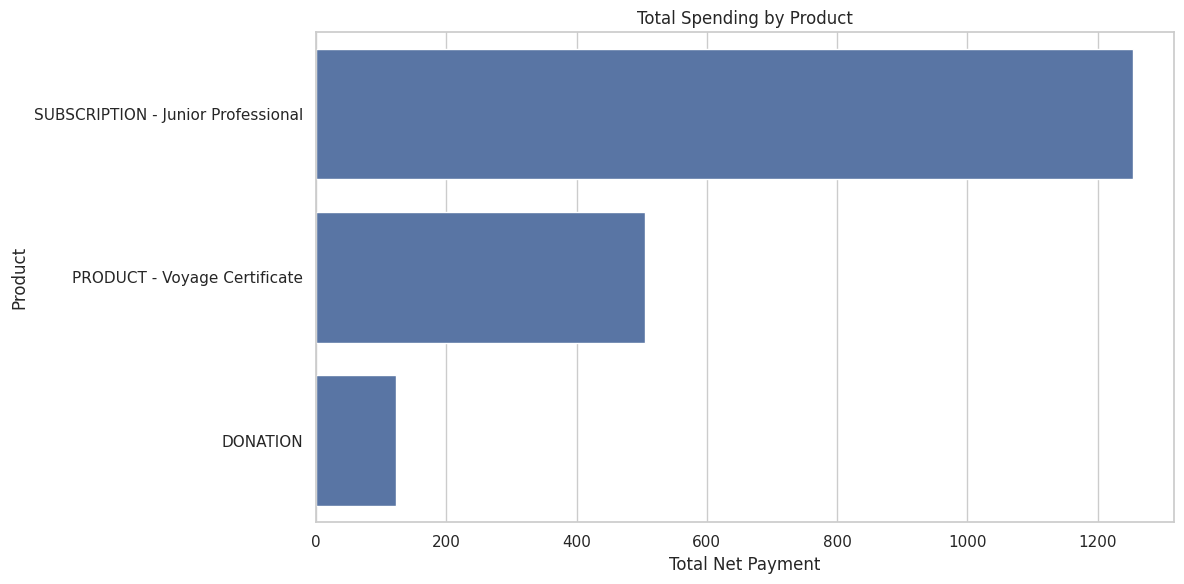

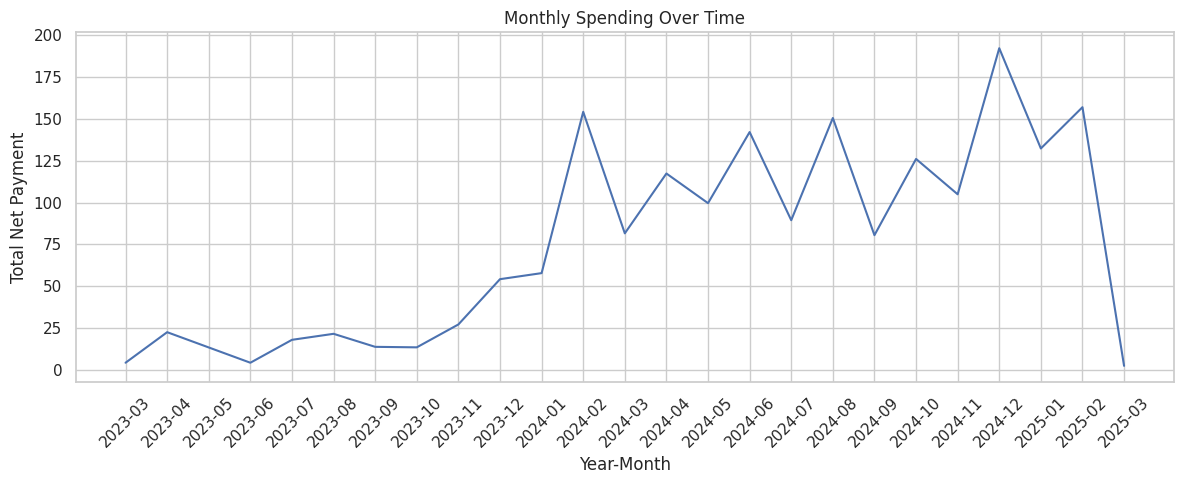

In [129]:
# Plot Average Spending Per Customer
plt.figure(figsize=(10, 5))
sns.histplot(average_spending_per_customer['net_payment'], kde=True, bins=30)
plt.title('Average Spending Per Customer')
plt.xlabel('Average Net Payment')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

# Plot Spending by Product
plt.figure(figsize=(12, 6))
sns.barplot(data=spending_by_product.sort_values(by='net_payment', ascending=False), x='net_payment', y='product')
plt.title('Total Spending by Product')
plt.xlabel('Total Net Payment')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

# Plot Spending per Month
spending_by_month['year_month'] = spending_by_month['year'].astype(str) + '-' + spending_by_month['month'].astype(str).str.zfill(2)
plt.figure(figsize=(12, 5))
sns.lineplot(data=spending_by_month, x='year_month', y='net_payment')
plt.title('Monthly Spending Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Total Net Payment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [130]:
# Mean Payment Amount by Subscription Status
correlation_transaction_subscription = df_transactions.groupby('subscription_status')['net_payment'].mean().reset_index()

# Mean Payment Amount by Product
correlation_transaction_product = df_transactions.groupby('product')['net_payment'].mean().reset_index()

# Display results
print("Correlation between Transaction Amount and Subscription Status:")
display(correlation_transaction_subscription)

print("\nCorrelation between Transaction Amount and Product Type:")
display(correlation_transaction_product)

Correlation between Transaction Amount and Subscription Status:


,subscription_status,net_payment
0,active,2.661150
1,ended,2.679172
2,no-subscription,3.612011



Correlation between Transaction Amount and Product Type:


,product,net_payment
0,DONATION,3.417778
1,PRODUCT - Voyage Certificate,3.655725
2,SUBSCRIPTION - Junior Professional,2.669213


In [131]:
df_transactions.drop(columns = ['unique_id'], inplace = True)
from category_encoders import BinaryEncoder
# Select categorical columns

categorical_columns = df_transactions.select_dtypes(include=['object', 'category']).columns.tolist()

# Binary encode categorical columns using category_encoders
encoder = BinaryEncoder(cols=categorical_columns)
df_transactions_encoded = encoder.fit_transform(df_transactions)


In [132]:
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 644 entries, 18 to 878
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   transaction_date     644 non-null    datetime64[ns]
 1   subscription_status  644 non-null    object        
 2   payment_source       644 non-null    object        
 3   product              644 non-null    object        
 4   certificate_voyage   644 non-null    object        
 5   transaction_fee      644 non-null    float64       
 6   net_payment          644 non-null    float64       
 7   day_of_Week          644 non-null    int32         
 8   month                644 non-null    int32         
 9   year                 644 non-null    int32         
dtypes: datetime64[ns](1), float64(2), int32(3), object(4)
memory usage: 47.8+ KB


In [139]:
# Regression Model: Predict net_payment for a unique_id
X = df_transactions_encoded.drop(columns=['net_payment', 'transaction_date'])
y = df_transactions_encoded['net_payment']
print(X.info())
X_intera , X_extra , y_intera, y_extra = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_intera, y_intera, test_size=0.3, random_state=42)
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:\nMSE: {mse:.2f}\nR^2: {r2:.2f}")

<class 'pandas.core.frame.DataFrame'>
Index: 644 entries, 18 to 878
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   subscription_status_0  644 non-null    int64  
 1   subscription_status_1  644 non-null    int64  
 2   payment_source_0       644 non-null    int64  
 3   payment_source_1       644 non-null    int64  
 4   product_0              644 non-null    int64  
 5   product_1              644 non-null    int64  
 6   certificate_voyage_0   644 non-null    int64  
 7   certificate_voyage_1   644 non-null    int64  
 8   certificate_voyage_2   644 non-null    int64  
 9   certificate_voyage_3   644 non-null    int64  
 10  transaction_fee        644 non-null    float64
 11  day_of_Week            644 non-null    int32  
 12  month                  644 non-null    int32  
 13  year                   644 non-null    int32  
dtypes: float64(1), int32(3), int64(10)
memory usage: 67.9 KB
None


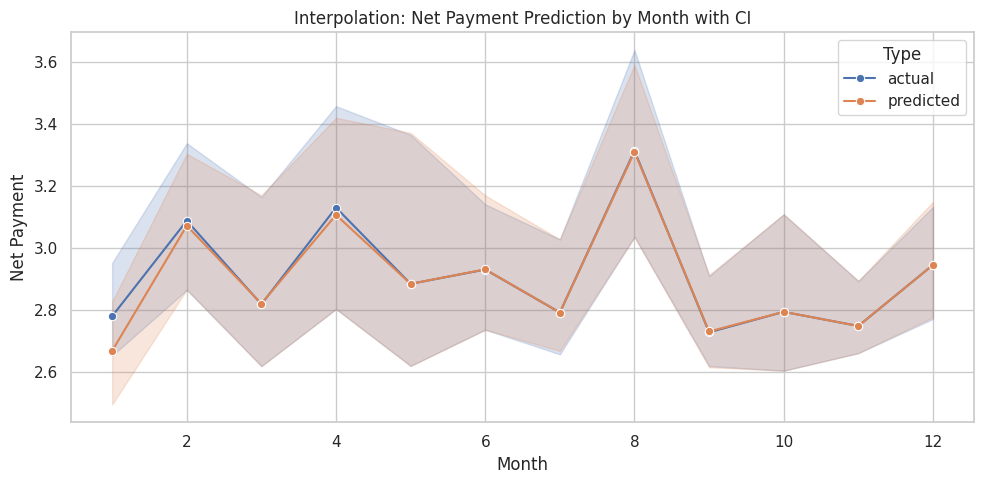

Model Performance:
MSE: 0.03
R^2: 0.90


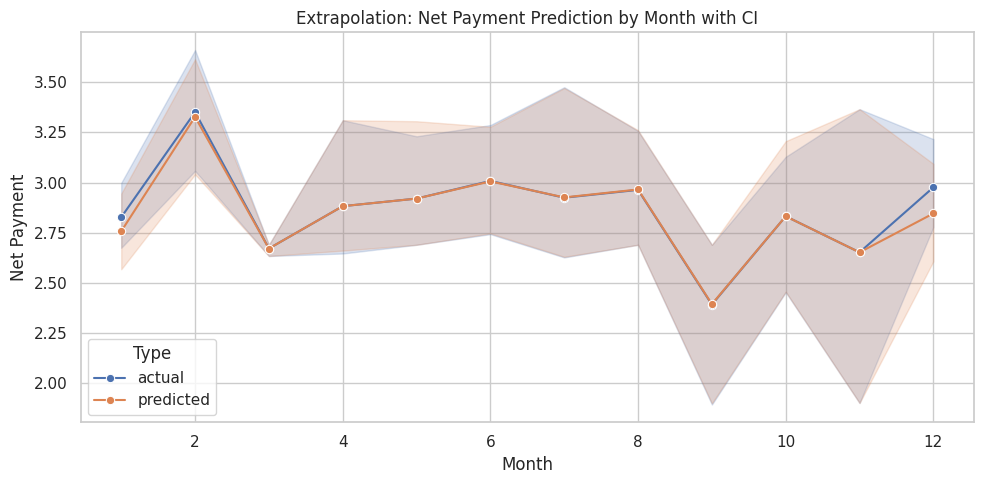

Model Performance:
MSE: 0.03
R^2: 0.90


In [134]:
# Interpolation: Smooth lineplot with CI
X_test_plot = X_test.copy()
X_test_plot['actual'] = y_test.values
X_test_plot['predicted'] = y_pred
X_test_plot = X_test_plot[['month', 'actual', 'predicted']].melt(id_vars='month', var_name='Type', value_name='Net Payment')

plt.figure(figsize=(10, 5))
sns.lineplot(data=X_test_plot, x='month', y='Net Payment', hue='Type', ci=95, marker='o')
plt.title('Interpolation: Net Payment Prediction by Month with CI')
plt.xlabel('Month')
plt.ylabel('Net Payment')
plt.tight_layout()
plt.show()
print(f"Model Performance:\nMSE: {mse:.2f}\nR^2: {r2:.2f}")

# Extrapolation: Same for held-out data
y_extra_pred = model.predict(X_extra)
X_extra_plot = X_extra.copy()
X_extra_plot['actual'] = y_extra.values
X_extra_plot['predicted'] = y_extra_pred
X_extra_plot = X_extra_plot[['month', 'actual', 'predicted']].melt(id_vars='month', var_name='Type', value_name='Net Payment')

plt.figure(figsize=(10, 5))
sns.lineplot(data=X_extra_plot, x='month', y='Net Payment', hue='Type', ci=95, marker='o')
plt.title('Extrapolation: Net Payment Prediction by Month with CI')
plt.xlabel('Month')
plt.ylabel('Net Payment')
plt.tight_layout()
plt.show()
print(f"Model Performance:\nMSE: {mse:.2f}\nR^2: {r2:.2f}")

In [135]:
subscription_statuses = df_transactions['subscription_status'].unique()
payment_sources = df_transactions['payment_source'].unique()
products = df_transactions['product'].unique()
certificates = df_transactions['certificate_voyage'].unique()

# Generate synthetic data for Jan–Dec 2025
months = list(range(1, 13))
sample_data = []

for month in months:
    sample_data.append({
        'month': month,
        'year': 2025,
        'day_of_Week': 2,  # Placeholder: let's assume a Tuesday (can be refined later)
        'subscription_status': np.random.choice(subscription_statuses),
        'payment_source': np.random.choice(payment_sources),
        'product': np.random.choice(products),
        'certificate_voyage': np.random.choice(certificates),
        'transaction_fee': 0.0  # Common value in your data
    })

# Create DataFrame
df_2025_sample = pd.DataFrame(sample_data)

In [141]:
df = df_transactions
df['year_month'] = pd.to_datetime(df['transaction_date']).dt.to_period('M')
monthly_net = df.groupby('year_month')['net_payment'].sum()
monthly_net.index = monthly_net.index.to_timestamp()

In [142]:
from statsmodels.tsa.stattools import adfuller
adfuller(monthly_net)

(np.float64(-1.4703909605231358),
 np.float64(0.548104373355723),
 3,
 21,
 {'1%': np.float64(-3.7883858816542486),
  '5%': np.float64(-3.013097747543462),
  '10%': np.float64(-2.6463967573696143)},
 np.float64(157.66325978374235))

In [143]:
from statsmodels.tsa.arima.model import ARIMA

# ARMA(p, q) is ARIMA(p, 0, q)
model = ARIMA(monthly_net, order=(2, 0, 2))
results = model.fit()

In [144]:
forecast = results.get_forecast(steps=12)
predicted_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

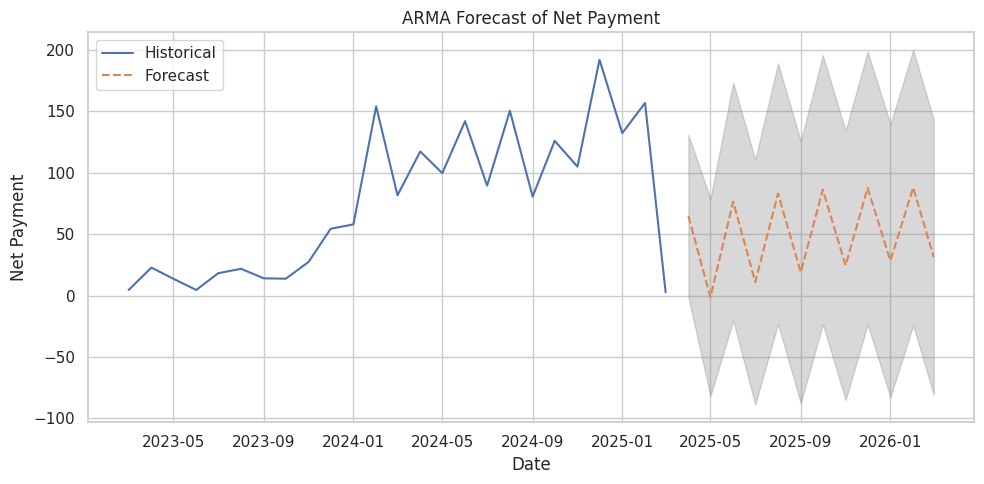

In [145]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_net, label='Historical')
plt.plot(predicted_mean.index, predicted_mean.values, label='Forecast', linestyle='--')
plt.fill_between(predicted_mean.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='gray', alpha=0.3)
plt.title('ARMA Forecast of Net Payment')
plt.xlabel('Date')
plt.ylabel('Net Payment')
plt.legend()
plt.tight_layout()
plt.show()

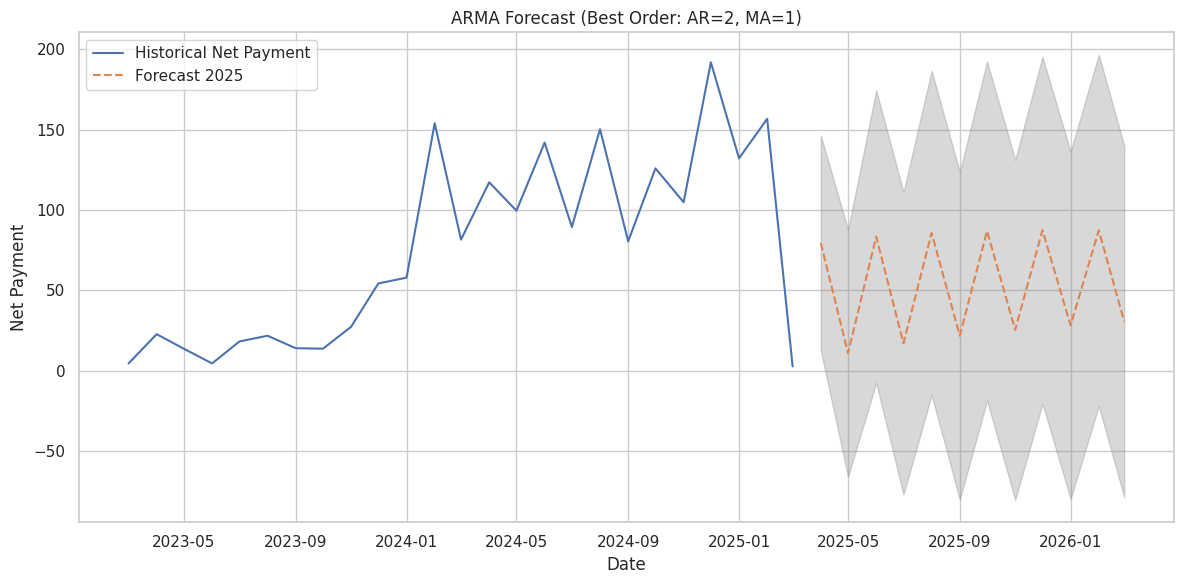

((2, 1), np.float64(259.877927737531))

In [146]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

# Try ARMA models for (p, q) where p and q range from 0 to 4
best_aic = np.inf
best_order = None
best_model = None

for p in range(5):
    for q in range(5):
        try:
            model = ARIMA(monthly_net, order=(p, 0, q))
            results = model.fit()
            if results.aic < best_aic:
                best_aic = results.aic
                best_order = (p, q)
                best_model = results
        except:
            continue

# Forecast next 12 months using best model
forecast_result = best_model.get_forecast(steps=12)
predicted_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

# Plot historical + forecast
plt.figure(figsize=(12, 6))
plt.plot(monthly_net, label='Historical Net Payment')
plt.plot(predicted_mean.index, predicted_mean.values, label='Forecast 2025', linestyle='--')
plt.fill_between(predicted_mean.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='gray', alpha=0.3)
plt.title(f'ARMA Forecast (Best Order: AR={best_order[0]}, MA={best_order[1]})')
plt.xlabel('Date')
plt.ylabel('Net Payment')
plt.legend()
plt.tight_layout()
plt.show()

best_order, best_aic
